In [1]:
!pip install rasterio

     |████████████████████████████████| 19.3 MB 1.2 MB/s 


In [2]:
!wget https://media.githubusercontent.com/media/StratagemGIS/files/main/altum_sample_cropped.tif

--2021-08-09 20:58:50--  https://media.githubusercontent.com/media/StratagemGIS/files/main/altum_sample_cropped.tif
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58298050 (56M) [image/tiff]
Saving to: ‘altum_sample_cropped.tif’

altum_sample_croppe 100%[===================>]  55.60M   183MB/s    in 0.3s    

2021-08-09 20:58:52 (183 MB/s) - ‘altum_sample_cropped.tif’ saved [58298050/58298050]



In [22]:
import matplotlib.pyplot as plt
import rasterio.plot as ras_plot
import rasterio as rio

In [7]:
bands = ['Blue', 'Green', 'Red', 'RedEdge', 'Near-IR', 'LWIR']

In [14]:
with rio.open('altum_sample_cropped.tif') as src:
    data = src.read()
    print(data.shape)

(6, 1578, 3078)


In [13]:
for band, band_data in zip(bands, data):
    print([band, band_data.min(), band_data.max(), band_data.mean(), band_data.std()])

['Blue', 1, 6980, 1437.041270647162, 1052.3205736729103]
['Green', 1, 13000, 2460.656925019209, 1381.8415399356693]
['Red', 1, 12801, 2587.053567119696, 2017.8648173730562]
['RedEdge', 1, 22185, 4985.381682507447, 1990.1926841177574]
['Near-IR', 1, 34726, 8513.801214679424, 4163.957722655957]
['LWIR', 28668, 30681, 29603.020199774186, 432.6412966709343]


In [15]:
with rio.open('altum_sample_cropped.tif') as src:
    data = src.read([2, 4])
    print(data.shape)

(2, 1578, 3078)


In [44]:
with rio.open('altum_sample_cropped.tif') as src:
    blue = src.read(1)
    print(blue.shape)

(1578, 3078)


In [39]:
with rio.open('altum_sample_cropped.tif') as src:
    rgb = src.read([3, 2, 1], out_dtype='float32')
    print(rgb.shape)

(3, 1578, 3078)


In [40]:
for i in range(3):
    rgb[i] = (rgb[i] - rgb[i].min()) / (rgb[i].max() - rgb[i].min())

In [41]:
rgb_plot = ras_plot.reshape_as_image(rgb)
rgb_plot.shape

(1578, 3078, 3)

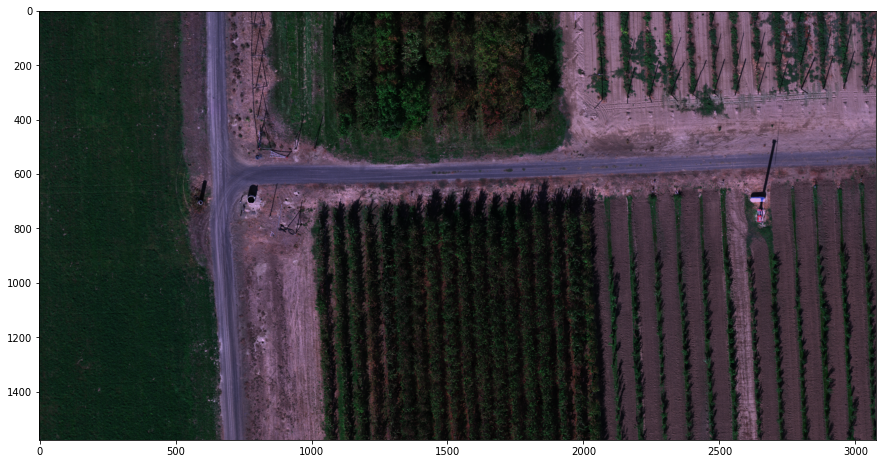

In [43]:
plt.figure(figsize=(15, 10))
plt.imshow(rgb_plot);

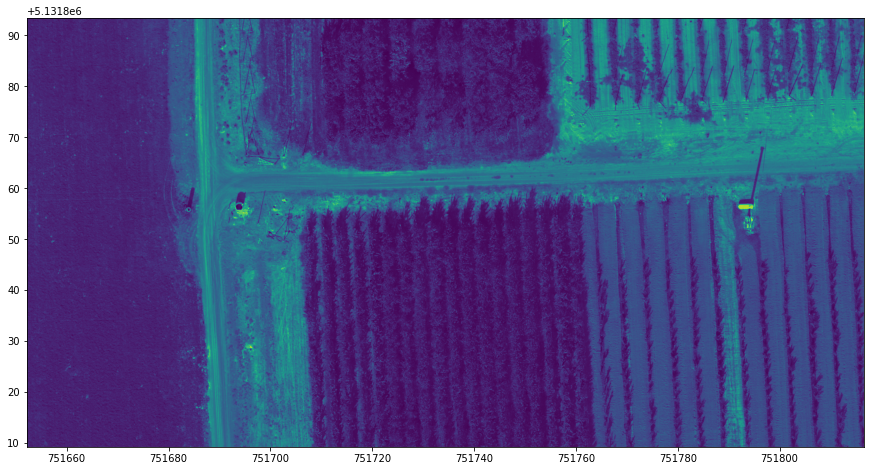

In [45]:
plt.figure(figsize=(15, 10))
with rio.open('altum_sample_cropped.tif') as src:
    ras_plot.show(src)